# Mutual Fund Performance Analysis
This notebook performs a comprehensive performance analysis of 40 mutual fund schemes, including returns, risk ratios, and benchmark comparisons.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
sns.set(style="whitegrid")
%matplotlib inline

## 1. Load and Preprocess Data

In [2]:
# Load Data
fund_master = pd.read_csv('../data/processed/01_fund_master_cleaned.csv')
nav_history = pd.read_csv('../data/processed/02_nav_history_cleaned.csv')
benchmarks = pd.read_csv('../data/processed/10_benchmark_indices_cleaned.csv')

# Preprocess dates
nav_history['date'] = pd.to_datetime(nav_history['date'])
benchmarks['date'] = pd.to_datetime(benchmarks['date'])

# Pivot NAV data
nav_pivoted = nav_history.pivot(index='date', columns='amfi_code', values='nav')
nav_pivoted = nav_pivoted.ffill().bfill()

# Pivot Benchmark data
bench_pivoted = benchmarks.pivot(index='date', columns='index_name', values='close_value')
bench_pivoted = bench_pivoted.ffill().bfill()

# Get scheme names mapping
code_to_name = dict(zip(fund_master['amfi_code'], fund_master['scheme_name']))
nav_pivoted.columns = [code_to_name.get(col, col) for col in nav_pivoted.columns]

print(f"Loaded {len(nav_pivoted.columns)} schemes and {len(bench_pivoted.columns)} benchmarks.")

Loaded 40 schemes and 7 benchmarks.


## 2. Compute Daily Returns
Formula: $r_t = \frac{NAV_t}{NAV_{t-1}} - 1$

In [3]:
daily_returns = nav_pivoted.pct_change().dropna()
bench_returns = bench_pivoted.pct_change().dropna()

# Display first few returns
daily_returns.iloc[:5, :5]

,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,ABSL Frontline Equity Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth
date,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766
2022-01-08,0.000000,0.000000,0.000000,0.000000,0.000000


## 3. Compute CAGR (1yr, 3yr, 5yr)
Formula: $CAGR = \left(\frac{NAV_{end}}{NAV_{start}}\right)^{\frac{1}{n}} - 1$

In [4]:
def calculate_cagr(series, years):
    if len(series) < 2:
        return np.nan
    
    end_date = series.index[-1]
    start_date = end_date - pd.DateOffset(years=years)
    
    # Find closest date in index
    idx = series.index.get_indexer([start_date], method='nearest')[0]
    actual_start_date = series.index[idx]
    
    nav_start = series.iloc[idx]
    nav_end = series.iloc[-1]
    
    # Actual years difference
    actual_years = (end_date - actual_start_date).days / 365.25
    
    if actual_years == 0:
        return np.nan
        
    cagr = (nav_end / nav_start) ** (1 / actual_years) - 1
    return cagr

cagr_1y = nav_pivoted.apply(lambda x: calculate_cagr(x, 1))
cagr_3y = nav_pivoted.apply(lambda x: calculate_cagr(x, 3))
cagr_5y = nav_pivoted.apply(lambda x: calculate_cagr(x, 5))

cagr_table = pd.DataFrame({
    '1Yr CAGR': cagr_1y,
    '3Yr CAGR': cagr_3y,
    '5Yr CAGR': cagr_5y
})

cagr_table.sort_values('3Yr CAGR', ascending=False).head(10)

,1Yr CAGR,3Yr CAGR,5Yr CAGR
Axis Midcap Fund - Regular - Growth,0.222779,0.351025,0.282144
Mirae Asset Large Cap Fund - Regular - Growth,0.203760,0.339920,0.309741
ICICI Pru Bluechip Fund - Direct - Growth,0.130738,0.324789,0.232951
HDFC Mid-Cap Opportunities Fund - Regular - Growth,0.532772,0.324340,0.301232
ICICI Pru Midcap Fund - Regular - Growth,0.296277,0.317692,0.328274
SBI Bluechip Fund - Regular Plan - Growth,0.604893,0.304486,0.258047
Kotak Flexicap Fund - Regular - Growth,0.266776,0.295751,0.309075
Mirae Asset Tax Saver Fund - Regular - Growth,0.397838,0.291714,0.319495
ABSL Frontline Equity Fund - Regular - Growth,0.479638,0.289602,0.235384
DSP Small Cap Fund - Regular - Growth,0.651955,0.269935,0.322874


## 4. Risk Ratios (Sharpe and Sortino)
Sharpe Ratio: $\frac{R_p - R_f}{\sigma_p} \times \sqrt{252}$

Sortino Ratio: $\frac{R_p - R_f}{\sigma_{downside}} \times \sqrt{252}$

In [5]:
Rf = 0.065 / 252 # Daily risk free rate
excess_returns = daily_returns - Rf

# Sharpe Ratio
sharpe_ratios = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)

# Sortino Ratio
downside_returns = daily_returns.copy()
downside_returns[downside_returns > 0] = 0
sortino_ratios = (excess_returns.mean() / downside_returns.std()) * np.sqrt(252)

risk_ratios = pd.DataFrame({
    'Sharpe Ratio': sharpe_ratios,
    'Sortino Ratio': sortino_ratios
})

risk_ratios.sort_values('Sharpe Ratio', ascending=False).head(10)

,Sharpe Ratio,Sortino Ratio
Mirae Asset Large Cap Fund - Regular - Growth,1.068224,1.833984
Kotak Flexicap Fund - Regular - Growth,0.965561,1.721085
Mirae Asset Tax Saver Fund - Regular - Growth,0.919047,1.604351
ICICI Pru Midcap Fund - Regular - Growth,0.883256,1.529594
SBI Bluechip Fund - Regular Plan - Growth,0.860977,1.514097
DSP Midcap Fund - Regular - Growth,0.832885,1.404155
HDFC Mid-Cap Opportunities Fund - Regular - Growth,0.808268,1.378385
Nippon India Large Cap Fund - Regular - Growth,0.758851,1.303589
Axis Midcap Fund - Regular - Growth,0.730547,1.261735
ABSL Frontline Equity Fund - Regular - Growth,0.717409,1.247564


## 5. Alpha and Beta
Computed using OLS regression against NIFTY 100.

In [6]:
nifty100_returns = bench_returns['NIFTY100']

alpha_beta_results = []
for col in daily_returns.columns:
    common_idx = daily_returns[col].index.intersection(nifty100_returns.index)
    y = daily_returns.loc[common_idx, col]
    x = nifty100_returns.loc[common_idx]
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    alpha = intercept * 252 # Annualized
    beta = slope
    
    alpha_beta_results.append({'Scheme': col, 'Alpha': alpha, 'Beta': beta})

alpha_beta_df = pd.DataFrame(alpha_beta_results).set_index('Scheme')
alpha_beta_df.head(10)

,Alpha,Beta
Scheme,,
HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268
HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158
HDFC Mid-Cap Opportunities Fund - Regular - Growth,0.271954,0.005104
ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289
ABSL Liquid Fund - Regular - Growth,0.060861,0.000267
UTI Nifty 50 Index Fund - Regular - Growth,0.170488,-0.019487
UTI Mid Cap Fund - Regular - Growth,0.028969,-0.042125
UTI Flexi Cap Fund - Regular - Growth,0.162113,0.016683


## 6. Maximum Drawdown
Formula: $min\left(\frac{NAV}{RunningMax} - 1\right)$

In [7]:
def calculate_max_drawdown(series):
    rolling_max = series.cummax()
    drawdown = (series / rolling_max) - 1
    return drawdown.min()

max_drawdowns = nav_pivoted.apply(calculate_max_drawdown)
max_drawdowns.sort_values().head(10) # Worst drawdowns

SBI Small Cap Fund - Direct Plan - Growth        -0.525742
Axis Small Cap Fund - Regular - Growth           -0.516778
ABSL Small Cap Fund - Regular - Growth           -0.354469
DSP Small Cap Fund - Regular - Growth            -0.311719
SBI Small Cap Fund - Regular Plan - Growth       -0.287060
UTI Mid Cap Fund - Regular - Growth              -0.280011
HDFC Top 100 Fund - Regular Plan - Growth        -0.247344
Kotak Emerging Equity Fund - Regular - Growth    -0.240035
Nippon India Small Cap Fund - Regular - Growth   -0.233449
Axis Bluechip Fund - Direct - Growth             -0.217514
dtype: float64

## 7. Fund Scorecard
Composite Score = 30% � 3yr return rank + 25% � Sharpe rank + 20% � Alpha rank + 15% � expense ratio rank (inverse) + 10% � max DD rank (inverse).

In [8]:
scorecard = pd.DataFrame(index=nav_pivoted.columns)
scorecard['3yr_return'] = cagr_3y
scorecard['sharpe'] = sharpe_ratios
scorecard['alpha'] = alpha_beta_df['Alpha']
scorecard['expense_ratio'] = fund_master.set_index('scheme_name')['expense_ratio_pct']
scorecard['max_dd'] = max_drawdowns

# Ranks (Higher is better)
scorecard['rank_3yr'] = scorecard['3yr_return'].rank(pct=True)
scorecard['rank_sharpe'] = scorecard['sharpe'].rank(pct=True)
scorecard['rank_alpha'] = scorecard['alpha'].rank(pct=True)
scorecard['rank_expense'] = scorecard['expense_ratio'].rank(pct=True, ascending=False)
scorecard['rank_max_dd'] = scorecard['max_dd'].rank(pct=True)

scorecard['Score'] = (
    0.30 * scorecard['rank_3yr'] +
    0.25 * scorecard['rank_sharpe'] +
    0.20 * scorecard['rank_alpha'] +
    0.15 * scorecard['rank_expense'] +
    0.10 * scorecard['rank_max_dd']
) * 100

scorecard.sort_values('Score', ascending=False).head(10)

,3yr_return,sharpe,alpha,expense_ratio,max_dd,rank_3yr,rank_sharpe,rank_alpha,rank_expense,rank_max_dd,Score
Mirae Asset Large Cap Fund - Regular - Growth,0.339920,1.068224,0.269838,1.46,-0.112657,0.975,1.000,0.850,0.4500,0.825,86.2500
ICICI Pru Midcap Fund - Regular - Growth,0.317692,0.883256,0.292636,1.36,-0.181885,0.900,0.925,0.950,0.6500,0.400,82.8750
Kotak Flexicap Fund - Regular - Growth,0.295751,0.965561,0.273305,1.45,-0.129740,0.850,0.975,0.900,0.4750,0.700,82.0000
HDFC Mid-Cap Opportunities Fund - Regular - Growth,0.324340,0.808268,0.271954,1.38,-0.162172,0.925,0.850,0.875,0.6000,0.525,80.7500
ICICI Pru Bluechip Fund - Direct - Growth,0.324789,0.714682,0.211948,0.80,-0.125883,0.950,0.750,0.700,0.7250,0.725,79.3750
Axis Midcap Fund - Regular - Growth,0.351025,0.730547,0.260767,1.38,-0.209609,1.000,0.800,0.800,0.6000,0.325,78.2500
SBI Bluechip Fund - Regular Plan - Growth,0.304486,0.860977,0.232010,1.54,-0.150124,0.875,0.900,0.775,0.2625,0.600,74.1875
Mirae Asset Tax Saver Fund - Regular - Growth,0.291714,0.919047,0.282704,1.60,-0.163967,0.825,0.950,0.925,0.1125,0.500,73.6875
SBI Small Cap Fund - Regular Plan - Growth,0.266631,0.711690,0.303370,1.43,-0.287060,0.725,0.700,1.000,0.5000,0.125,68.0000
ABSL Frontline Equity Fund - Regular - Growth,0.289602,0.717409,0.213998,1.60,-0.112916,0.800,0.775,0.725,0.1125,0.800,67.5625


## 8. Tracking Error
Formula: $std(r_{fund} - r_{benchmark}) \times \sqrt{252}$

In [9]:
bm_map = {
    'NIFTY 100 TRI': 'NIFTY100',
    'NIFTY 50 TRI': 'NIFTY50',
    'NIFTY Midcap 150 TRI': 'NIFTY_MIDCAP150',
    'BSE 250 SmallCap TRI': 'BSE_SMALLCAP',
    'CRISIL Dynamic Gilt Index': 'CRISIL_GILT',
    'CRISIL Liquid Fund Index': 'CRISIL_LIQUID'
}

tracking_errors = {}
for fund in nav_pivoted.columns:
    bm_name = fund_master[fund_master['scheme_name'] == fund]['benchmark'].values[0]
    mapped_bm = bm_map.get(bm_name, 'NIFTY50')
    
    fund_ret = daily_returns[fund]
    bm_ret = bench_returns[mapped_bm]
    
    common_idx = fund_ret.index.intersection(bm_ret.index)
    tracking_error = (fund_ret.loc[common_idx] - bm_ret.loc[common_idx]).std() * np.sqrt(252)
    tracking_errors[fund] = tracking_error

scorecard['Tracking Error'] = pd.Series(tracking_errors)
scorecard[['Score', 'Tracking Error']].sort_values('Score', ascending=False).head(10)

,Score,Tracking Error
Mirae Asset Large Cap Fund - Regular - Growth,86.2500,0.189664
ICICI Pru Midcap Fund - Regular - Growth,82.8750,0.262847
Kotak Flexicap Fund - Regular - Growth,82.0000,0.205148
HDFC Mid-Cap Opportunities Fund - Regular - Growth,80.7500,0.256247
ICICI Pru Bluechip Fund - Direct - Growth,79.3750,0.191587
Axis Midcap Fund - Regular - Growth,78.2500,0.237071
SBI Bluechip Fund - Regular Plan - Growth,74.1875,0.191183
Mirae Asset Tax Saver Fund - Regular - Growth,73.6875,0.219389
SBI Small Cap Fund - Regular Plan - Growth,68.0000,0.341892
ABSL Frontline Equity Fund - Regular - Growth,67.5625,0.192706


## 9. Benchmark Comparison Chart
Top 5 funds vs NIFTY 50 and NIFTY 100.

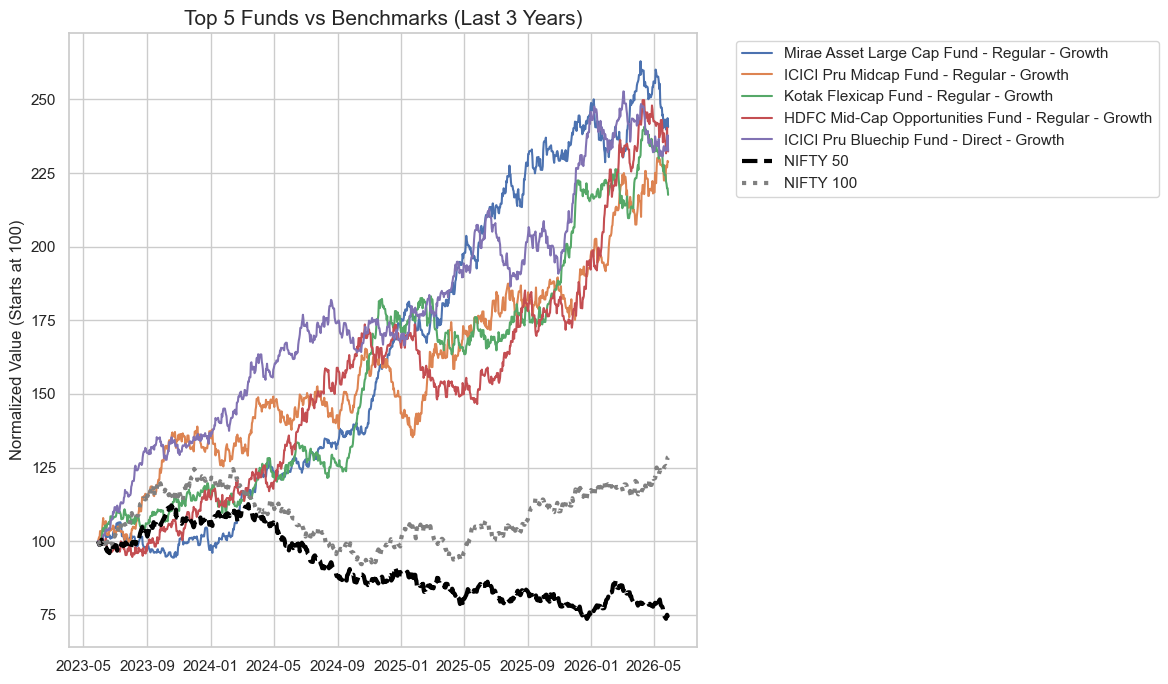

In [10]:
top_5_funds = scorecard['Score'].sort_values(ascending=False).head(5).index.tolist()

plt.figure(figsize=(12, 7))
three_years_ago = nav_pivoted.index[-1] - pd.DateOffset(years=3)
plot_data_funds = nav_pivoted.loc[three_years_ago:, top_5_funds]
plot_data_bench = bench_pivoted.loc[three_years_ago:, ['NIFTY50', 'NIFTY100']]

# Normalize
plot_data_funds = (plot_data_funds / plot_data_funds.iloc[0]) * 100
plot_data_bench = (plot_data_bench / plot_data_bench.iloc[0]) * 100

for col in plot_data_funds.columns:
    plt.plot(plot_data_funds.index, plot_data_funds[col], label=col)

plt.plot(plot_data_bench.index, plot_data_bench['NIFTY50'], label='NIFTY 50', linewidth=3, linestyle='--', color='black')
plt.plot(plot_data_bench.index, plot_data_bench['NIFTY100'], label='NIFTY 100', linewidth=3, linestyle=':', color='gray')

plt.title('Top 5 Funds vs Benchmarks (Last 3 Years)', fontsize=15)
plt.ylabel('Normalized Value (Starts at 100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 10. Export Deliverables

In [11]:
scorecard.to_csv('../fund_scorecard.csv')
alpha_beta_df.to_csv('../alpha_beta.csv')
print("Deliverables exported to root directory.")

Deliverables exported to root directory.
